# Импульсивные & Молочные

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

# ------------------- Даты -------------------
dates = pd.date_range(datetime(2025, 1, 1), datetime(2025, 3, 31))

# ------------------- Импульсивные товары -------------------
impulse_products = {
    "Шоколадка": {"base_qty": 20, "cost": 0.5, "price": 1.5},
    "Батончик / Снэк": {"base_qty": 15, "cost": 0.4, "price": 1.2},
    "Жевательная резинка": {"base_qty": 25, "cost": 0.2, "price": 0.5},
    "Печенье / вафли": {"base_qty": 18, "cost": 0.7, "price": 1.8},
    "Чипсы / сухарики": {"base_qty": 12, "cost": 0.6, "price": 1.5}
}

# ------------------- Молочные продукты -------------------
milk_products = {
    "Milk": {"base_qty": 20, "cost": 0.6, "price": 1.2},
    "Йогурт": {"base_qty": 15, "cost": 0.5, "price": 1.1},
    "Хлеб": {"base_qty": 25, "cost": 0.3, "price": 0.8},
    "Масло": {"base_qty": 10, "cost": 1.0, "price": 2.0},
    "Сыр": {"base_qty": 12, "cost": 1.5, "price": 2.8},
    "Кефир": {"base_qty": 18, "cost": 0.7, "price": 1.5}
}

# ------------------- Объединяем продукты -------------------
all_products = {**impulse_products, **milk_products}

# ------------------- Категории -------------------
product_category = {
    **{k: {"category": "Food", "sub_category": "Schoko_Snek"} for k in impulse_products},
    **{k: {"category": "Food", "sub_category": "Molochnie_produkti"} for k in milk_products}
}

# ------------------- Доступные скидки -------------------
discounts = [0, 5, 10, 15, 20, 25, 30, 40, 50]

# ------------------- Функции роста количества -------------------
def calc_qty(product, discount):
    if product in impulse_products:
        # рост для импульсивных товаров
        base = impulse_products[product]["base_qty"]
        mapping = {0: base, 5: base*1.3, 10: base*1.5, 15: base*1.7,
                   20: base*1.9, 25: base*2.0, 30: base*2.0, 40: base*2.0, 50: base*2.0}
    else:
        # рост для молочных товаров
        base = milk_products[product]["base_qty"]
        mapping = {0: base, 5: int(base*1.1), 10: int(base*1.2), 15: int(base*1.3),
                   20: int(base*1.35), 25: int(base*1.35), 30: int(base*1.35),
                   40: int(base*1.35), 50: int(base*1.35)}
    return mapping.get(discount, base)

# ------------------- Генерация данных -------------------
data = []
np.random.seed(42)

for date in dates:
    for product, params in all_products.items():
        discount = np.random.choice(discounts)
        qty = calc_qty(product, discount)
        price_discounted = params["price"] * (1 - discount/100)
        profit = (price_discounted - params["cost"]) * qty

        category = product_category[product]["category"]
        sub_category = product_category[product]["sub_category"]

        data.append([
            date, product, category, sub_category, qty,
            params["cost"], params["price"], discount,
            round(price_discounted,2), round(profit,2)
        ])

# ------------------- Создание DataFrame -------------------
df_all = pd.DataFrame(
    data,
    columns=[
        "Дата", "Продукт", "Категория", "Подкатегория", "Кол-во",
        "Себестоимость 1 шт (€)", "Цена без скидки (€)", "% скидки",
        "Цена со скидкой (€)", "Прибыль (€)"
    ]
)

# ------------------- Проверка -------------------
print(df_all.head(10))

# ------------------- Экспорт -------------------
df_all.to_excel("orders_all_products_combined.xlsx", index=False)


        Дата              Продукт Категория        Подкатегория  Кол-во  \
0 2025-01-01            Шоколадка      Food         Schoko_Snek    40.0   
1 2025-01-01      Батончик / Снэк      Food         Schoko_Snek    25.5   
2 2025-01-01  Жевательная резинка      Food         Schoko_Snek    50.0   
3 2025-01-01      Печенье / вафли      Food         Schoko_Snek    34.2   
4 2025-01-01     Чипсы / сухарики      Food         Schoko_Snek    24.0   
5 2025-01-01                 Milk      Food  Molochnie_produkti    24.0   
6 2025-01-01               Йогурт      Food  Molochnie_produkti    20.0   
7 2025-01-01                 Хлеб      Food  Molochnie_produkti    33.0   
8 2025-01-01                Масло      Food  Molochnie_produkti    13.0   
9 2025-01-01                  Сыр      Food  Molochnie_produkti    15.0   

   Себестоимость 1 шт (€)  Цена без скидки (€)  % скидки  Цена со скидкой (€)  \
0                     0.5                  1.5        30                 1.05   
1           

## График для Schoko_Snek & Molochnie_produkti

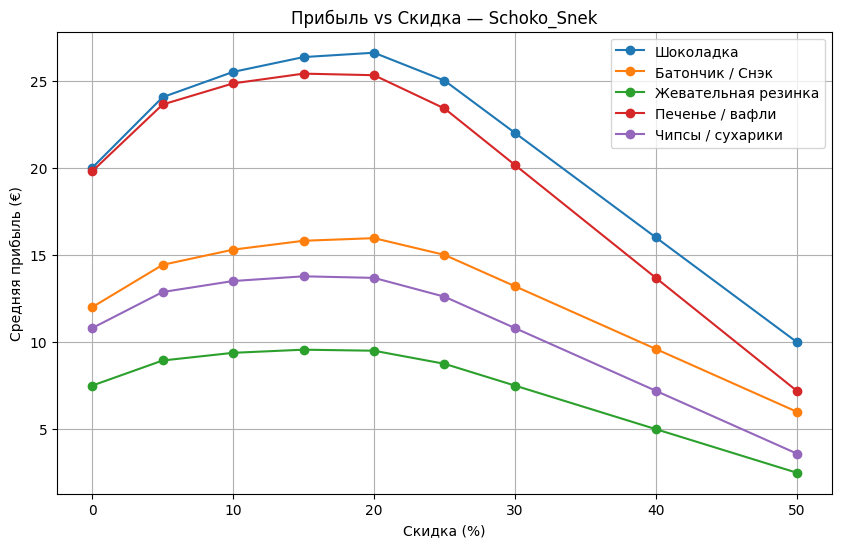

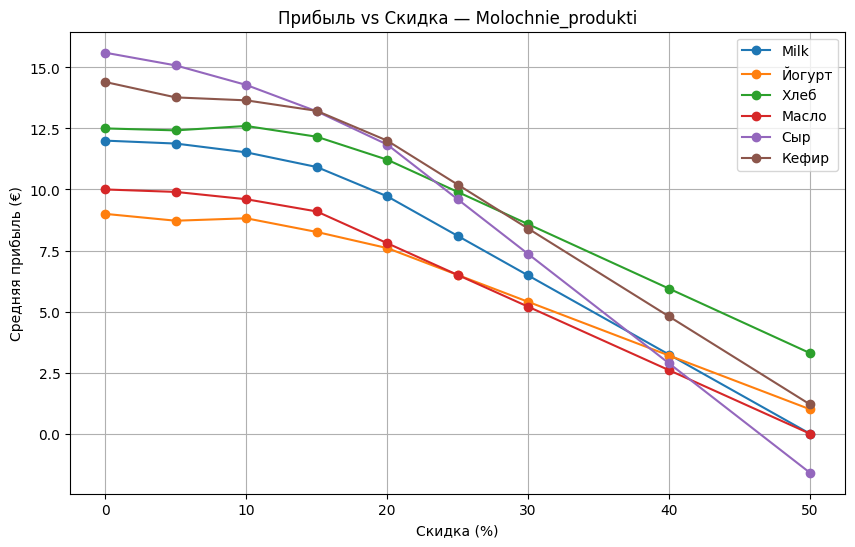

In [3]:
import matplotlib.pyplot as plt

# ------------------- График для Schoko_Snek -------------------
plt.figure(figsize=(10,6))
for product in df_all[df_all["Подкатегория"]=="Schoko_Snek"]["Продукт"].unique():
    df_p = (
        df_all[df_all["Продукт"]==product]
        .groupby("% скидки")["Прибыль (€)"]
        .mean()
        .reset_index()
        .sort_values("% скидки")
    )
    plt.plot(df_p["% скидки"], df_p["Прибыль (€)"], marker="o", label=product)

plt.xlabel("Скидка (%)")
plt.ylabel("Средняя прибыль (€)")
plt.title("Прибыль vs Скидка — Schoko_Snek")
plt.legend()
plt.grid(True)
plt.show()

# ------------------- График для Molochnie_produkti -------------------
plt.figure(figsize=(10,6))
for product in df_all[df_all["Подкатегория"]=="Molochnie_produkti"]["Продукт"].unique():
    df_p = (
        df_all[df_all["Продукт"]==product]
        .groupby("% скидки")["Прибыль (€)"]
        .mean()
        .reset_index()
        .sort_values("% скидки")
    )
    plt.plot(df_p["% скидки"], df_p["Прибыль (€)"], marker="o", label=product)

plt.xlabel("Скидка (%)")
plt.ylabel("Средняя прибыль (€)")
plt.title("Прибыль vs Скидка — Molochnie_produkti")
plt.legend()
plt.grid(True)
plt.show()


# Товары электроники

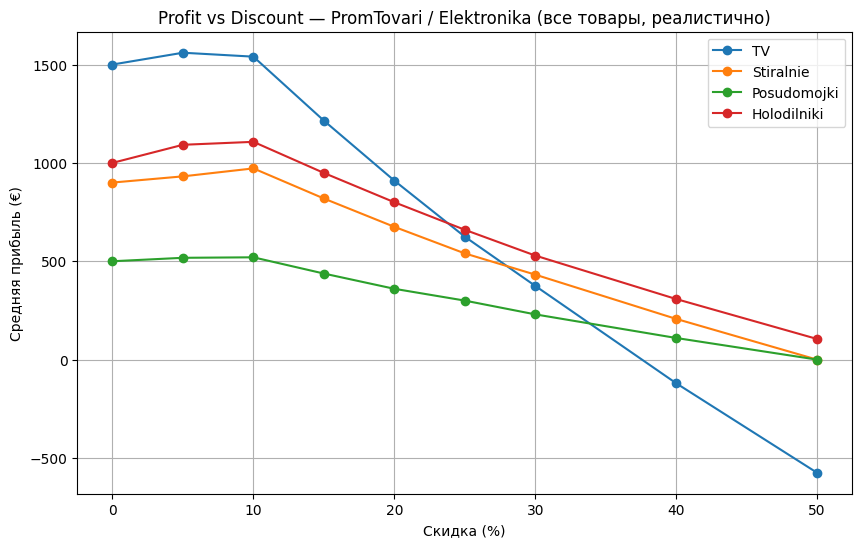

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# ------------------- Даты -------------------
dates = pd.date_range(datetime(2025,1,1), datetime(2025,3,31))

# ------------------- Товары электроники + реалистичный рост -------------------
electronics_products = {
    "TV": {"base_qty": 5, "cost": 500, "price": 800,
           "growth": {0:1.0, 5:1.2, 10:1.4, 15:1.35, 20:1.3, 25:1.25, 30:1.25, 40:1.2, 50:1.15}},
    "Stiralnie": {"base_qty": 3, "cost": 300, "price": 600,
                  "growth": {0:1.0, 5:1.15, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.2, 40:1.15, 50:1.1}},
    "Posudomojki": {"base_qty": 2, "cost": 250, "price": 500,
                     "growth": {0:1.0, 5:1.15, 10:1.3, 15:1.25, 20:1.2, 25:1.2, 30:1.15, 40:1.1, 50:1.05}},
    "Holodilniki": {"base_qty": 2, "cost": 400, "price": 900,
                     "growth": {0:1.0, 5:1.2, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.15, 40:1.1, 50:1.05}}
}

# ------------------- Доступные скидки -------------------
discounts = [0, 5, 10, 15, 20, 25, 30, 40, 50]

# ------------------- Генерация данных -------------------
data = []
np.random.seed(42)

for date in dates:
    for product, params in electronics_products.items():
        discount = np.random.choice(discounts)
        # Реалистичное количество
        qty = params["base_qty"] * params["growth"][discount]
        price_discounted = params["price"] * (1 - discount/100)
        profit = (price_discounted - params["cost"]) * qty

        data.append([
            date, product, "PromTovari", "Elektronika", int(qty),
            params["cost"], params["price"], discount,
            round(price_discounted,2), round(profit,2)
        ])

# ------------------- Создание DF -------------------
df_electronics_realistic = pd.DataFrame(
    data,
    columns=[
        "Дата", "Продукт", "Категория", "Подкатегория", "Кол-во",
        "Себестоимость 1 шт (€)", "Цена без скидки (€)", "% скидки",
        "Цена со скидкой (€)", "Прибыль (€)"
    ]
)

# ------------------- Экспорт -------------------
df_electronics_realistic.to_excel("orders_electronics_realistic.xlsx", index=False)

# ------------------- Построение графика -------------------
plt.figure(figsize=(10,6))

for product in df_electronics_realistic["Продукт"].unique():
    df_p = (
        df_electronics_realistic[df_electronics_realistic["Продукт"]==product]
        .groupby("% скидки")["Прибыль (€)"]
        .mean()
        .reset_index()
        .sort_values("% скидки")
    )
    plt.plot(df_p["% скидки"], df_p["Прибыль (€)"], marker="o", label=product)

plt.xlabel("Скидка (%)")
plt.ylabel("Средняя прибыль (€)")
plt.title("Profit vs Discount — PromTovari / Elektronika (все товары, реалистично)")
plt.legend()
plt.grid(True)
plt.show()


# Товары электроники, Импульсивные товары, Молочные продукты

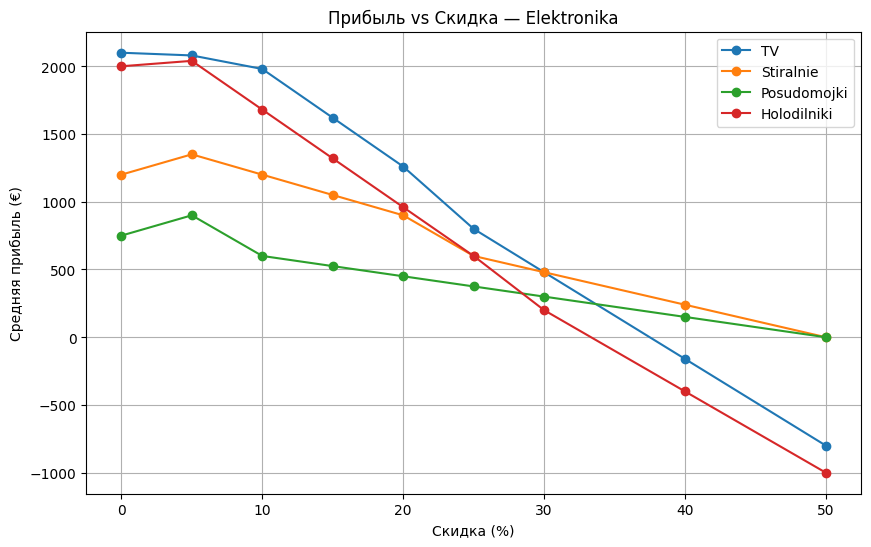

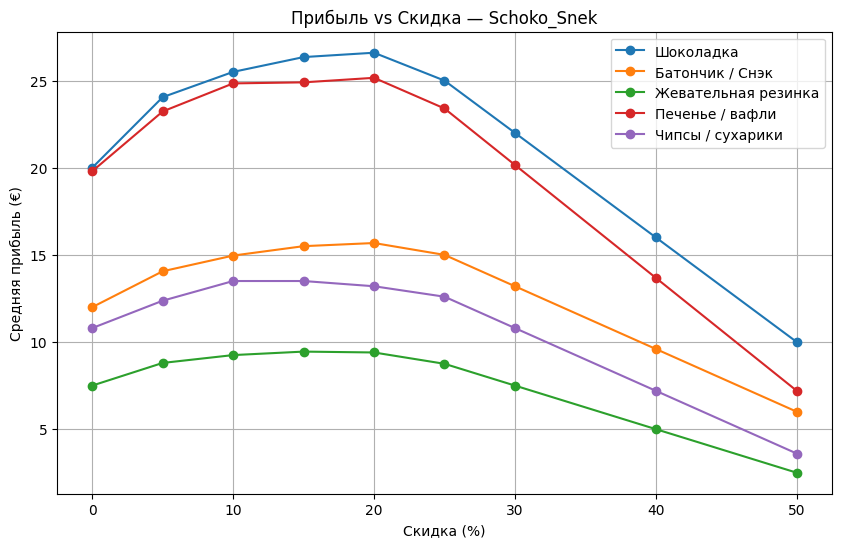

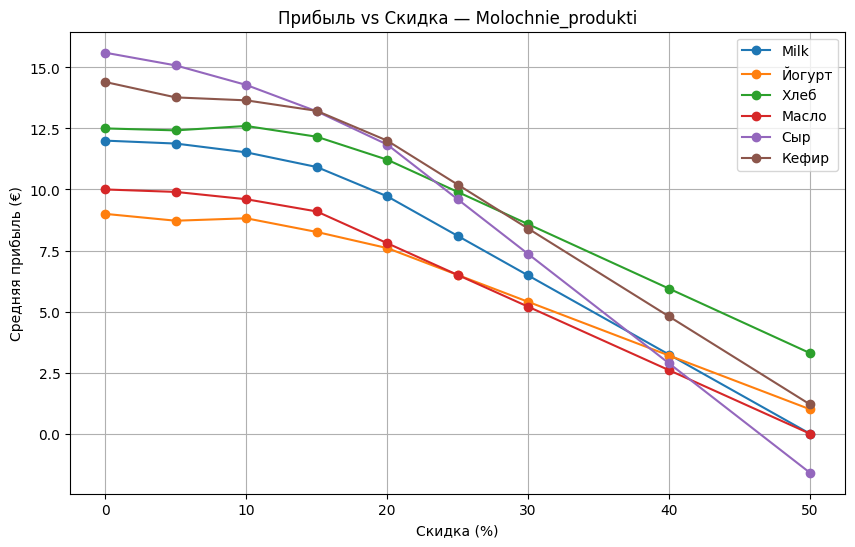

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# ------------------- Даты -------------------
dates = pd.date_range(datetime(2025,1,1), datetime(2025,3,31))

# ------------------- Товары электроники + реалистичный рост -------------------
electronics_products = {
    "TV":         {"base_qty": 7, "cost": 500, "price": 800,
                  "growth": {0:1.0, 5:1.2, 10:1.4, 15:1.35, 20:1.3, 25:1.25, 30:1.25, 40:1.2, 50:1.15}},
    "Stiralnie": {"base_qty": 4, "cost": 300, "price": 600,
                  "growth": {0:1.0, 5:1.25, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.2, 40:1.15, 50:1.1}},
    "Posudomojki": {"base_qty": 3, "cost": 250, "price": 500,
                     "growth": {0:1.0, 5:1.45, 10:1.3, 15:1.25, 20:1.2, 25:1.2, 30:1.15, 40:1.1, 50:1.05}},
    "Holodilniki": {"base_qty": 5, "cost": 800, "price": 1200,
                     "growth": {0:1.0, 5:1.39, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.15, 40:1.1, 50:1.05}}
}

# ------------------- Импульсивные товары -------------------
impulse_products = {
    "Шоколадка": {"base_qty": 20, "cost": 0.5, "price": 1.5},
    "Батончик / Снэк": {"base_qty": 15, "cost": 0.4, "price": 1.2},
    "Жевательная резинка": {"base_qty": 25, "cost": 0.2, "price": 0.5},
    "Печенье / вафли": {"base_qty": 18, "cost": 0.7, "price": 1.8},
    "Чипсы / сухарики": {"base_qty": 12, "cost": 0.6, "price": 1.5}
}

# ------------------- Молочные продукты -------------------
milk_products = {
    "Milk": {"base_qty": 20, "cost": 0.6, "price": 1.2},
    "Йогурт": {"base_qty": 15, "cost": 0.5, "price": 1.1},
    "Хлеб": {"base_qty": 25, "cost": 0.3, "price": 0.8},
    "Масло": {"base_qty": 10, "cost": 1.0, "price": 2.0},
    "Сыр": {"base_qty": 12, "cost": 1.5, "price": 2.8},
    "Кефир": {"base_qty": 18, "cost": 0.7, "price": 1.5}
}

# ------------------- Объединяем все продукты -------------------
all_products = {**electronics_products, **impulse_products, **milk_products}

# ------------------- Категории -------------------
product_category = {
    **{k: {"category": "PromTovari", "sub_category": "Elektronika"} for k in electronics_products},
    **{k: {"category": "Food", "sub_category": "Schoko_Snek"} for k in impulse_products},
    **{k: {"category": "Food", "sub_category": "Molochnie_produkti"} for k in milk_products}
}

# ------------------- Доступные скидки -------------------
discounts = [0, 5, 10, 15, 20, 25, 30, 40, 50]

# ------------------- Функции роста количества -------------------
def calc_qty(product, discount):
    if product in electronics_products:
        base = electronics_products[product]["base_qty"]
        qty = base * electronics_products[product]["growth"][discount]
    elif product in impulse_products:
        base = impulse_products[product]["base_qty"]
        mapping = {0: base, 5: base*1.3, 10: base*1.5, 15: base*1.7,
                   20: base*1.9, 25: base*2.0, 30: base*2.0, 40: base*2.0, 50: base*2.0}
        qty = mapping.get(discount, base)
    else:
        base = milk_products[product]["base_qty"]
        mapping = {0: base, 5: int(base*1.1), 10: int(base*1.2), 15: int(base*1.3),
                   20: int(base*1.35), 25: int(base*1.35), 30: int(base*1.35),
                   40: int(base*1.35), 50: int(base*1.35)}
        qty = mapping.get(discount, base)
    return int(qty)

# ------------------- Генерация данных -------------------
data = []
np.random.seed(42)

for date in dates:
    for product, params in all_products.items():
        discount = np.random.choice(discounts)
        qty = calc_qty(product, discount)
        price_discounted = params["price"] * (1 - discount/100)
        profit = (price_discounted - params["cost"]) * qty

        category = product_category[product]["category"]
        sub_category = product_category[product]["sub_category"]

        data.append([
            date, product, category, sub_category, qty,
            params["cost"], params["price"], discount,
            round(price_discounted,2), round(profit,2)
        ])

# ------------------- Создание DataFrame -------------------
df_all = pd.DataFrame(
    data,
    columns=[
        "Дата", "Продукт", "Категория", "Подкатегория", "Кол-во",
        "Себестоимость 1 шт (€)", "Цена без скидки (€)", "% скидки",
        "Цена со скидкой (€)", "Прибыль (€)"
    ]
)

# ------------------- Экспорт -------------------
df_all.to_excel("orders_all_products_combined_3.xlsx", index=False)

# ------------------- Построение графиков -------------------
for sub_cat in df_all["Подкатегория"].unique():
    plt.figure(figsize=(10,6))
    for product in df_all[df_all["Подкатегория"]==sub_cat]["Продукт"].unique():
        df_p = (
            df_all[df_all["Продукт"]==product]
            .groupby("% скидки")["Прибыль (€)"]
            .mean()
            .reset_index()
            .sort_values("% скидки")
        )
        plt.plot(df_p["% скидки"], df_p["Прибыль (€)"], marker="o", label=product)
    plt.xlabel("Скидка (%)")
    plt.ylabel("Средняя прибыль (€)")
    plt.title(f"Прибыль vs Скидка — {sub_cat}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
import pandas as pd

# Список скидок
discounts = [0, 5, 10, 15, 20, 25, 30, 40, 50]

# Текущие продукты и рост (из твоего скрипта)
electronics_products = {
    "TV": {"base_qty": 5, "growth": {0:1.0, 5:1.2, 10:1.4, 15:1.35, 20:1.3, 25:1.25, 30:1.25, 40:1.2, 50:1.15}},
    "Stiralnie": {"base_qty": 3, "growth": {0:1.0, 5:1.15, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.2, 40:1.15, 50:1.1}},
    "Posudomojki": {"base_qty": 2, "growth": {0:1.0, 5:1.15, 10:1.3, 15:1.25, 20:1.2, 25:1.2, 30:1.15, 40:1.1, 50:1.05}},
    "Holodilniki": {"base_qty": 2, "growth": {0:1.0, 5:1.2, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.15, 40:1.1, 50:1.05}}
}

impulse_products = {
    "Шоколадка": {"base_qty": 20},
    "Батончик / Снэк": {"base_qty": 15},
    "Жевательная резинка": {"base_qty": 25},
    "Печенье / вафли": {"base_qty": 18},
    "Чипсы / сухарики": {"base_qty": 12}
}

milk_products = {
    "Milk": {"base_qty": 20},
    "Йогурт": {"base_qty": 15},
    "Хлеб": {"base_qty": 25},
    "Масло": {"base_qty": 10},
    "Сыр": {"base_qty": 12},
    "Кефир": {"base_qty": 18}
}

all_products = {**electronics_products, **impulse_products, **milk_products}

# Функция для расчета количества по скидке
def get_qty(product_name, discount):
    if product_name in electronics_products:
        base = electronics_products[product_name]["base_qty"]
        growth = electronics_products[product_name]["growth"].get(discount, 1.0)
        return round(base * growth,2)
    elif product_name in impulse_products:
        base = impulse_products[product_name]["base_qty"]
        mapping = {0: base, 5: base*1.3, 10: base*1.5, 15: base*1.7,
                   20: base*1.9, 25: base*2.0, 30: base*2.0, 40: base*2.0, 50: base*2.0}
        return round(mapping.get(discount, base),2)
    else:
        base = milk_products[product_name]["base_qty"]
        mapping = {0: base, 5: base*1.1, 10: base*1.2, 15: base*1.3,
                   20: base*1.35, 25: base*1.35, 30: base*1.35, 40: base*1.35, 50: base*1.35}
        return round(mapping.get(discount, base),2)

# Генерация таблицы
growth_table = pd.DataFrame(index=discounts, columns=all_products.keys())

for product in all_products.keys():
    for discount in discounts:
        growth_table.loc[discount, product] = get_qty(product, discount)

growth_table.index.name = "Скидка (%)"

from IPython.display import display
display(growth_table)


,TV,Stiralnie,Posudomojki,Holodilniki,Шоколадка,Батончик / Снэк,Жевательная резинка,Печенье / вафли,Чипсы / сухарики,Milk,Йогурт,Хлеб,Масло,Сыр,Кефир
Скидка (%),,,,,,,,,,,,,,,
0,5.0,3.0,2.0,2.0,20,15,25,18,12,20,15,25,10,12,18
5,6.0,3.45,2.3,2.4,26.0,19.5,32.5,23.4,15.6,22.0,16.5,27.5,11.0,13.2,19.8
10,7.0,4.05,2.6,2.7,30.0,22.5,37.5,27.0,18.0,24.0,18.0,30.0,12.0,14.4,21.6
15,6.75,3.9,2.5,2.6,34.0,25.5,42.5,30.6,20.4,26.0,19.5,32.5,13.0,15.6,23.4
20,6.5,3.75,2.4,2.5,38.0,28.5,47.5,34.2,22.8,27.0,20.25,33.75,13.5,16.2,24.3
25,6.25,3.6,2.4,2.4,40.0,30.0,50.0,36.0,24.0,27.0,20.25,33.75,13.5,16.2,24.3
30,6.25,3.6,2.3,2.3,40.0,30.0,50.0,36.0,24.0,27.0,20.25,33.75,13.5,16.2,24.3
40,6.0,3.45,2.2,2.2,40.0,30.0,50.0,36.0,24.0,27.0,20.25,33.75,13.5,16.2,24.3
50,5.75,3.3,2.1,2.1,40.0,30.0,50.0,36.0,24.0,27.0,20.25,33.75,13.5,16.2,24.3


# DE

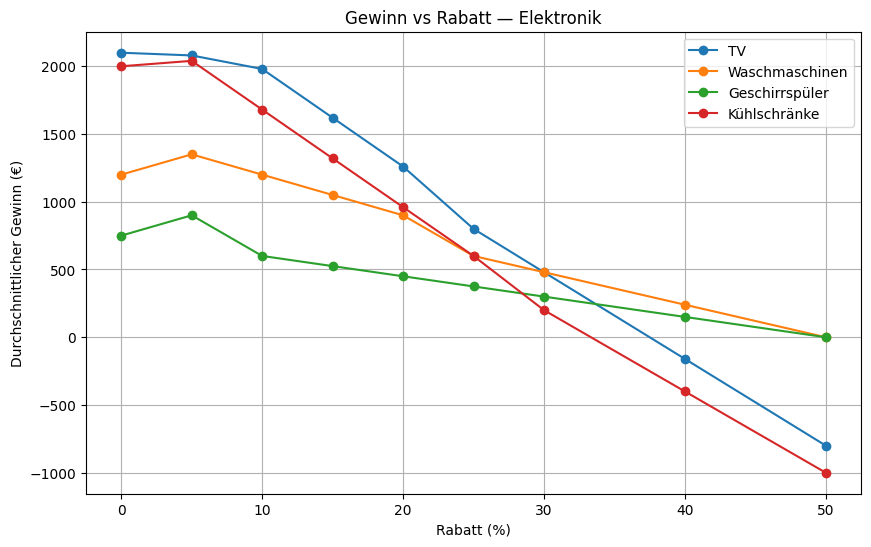

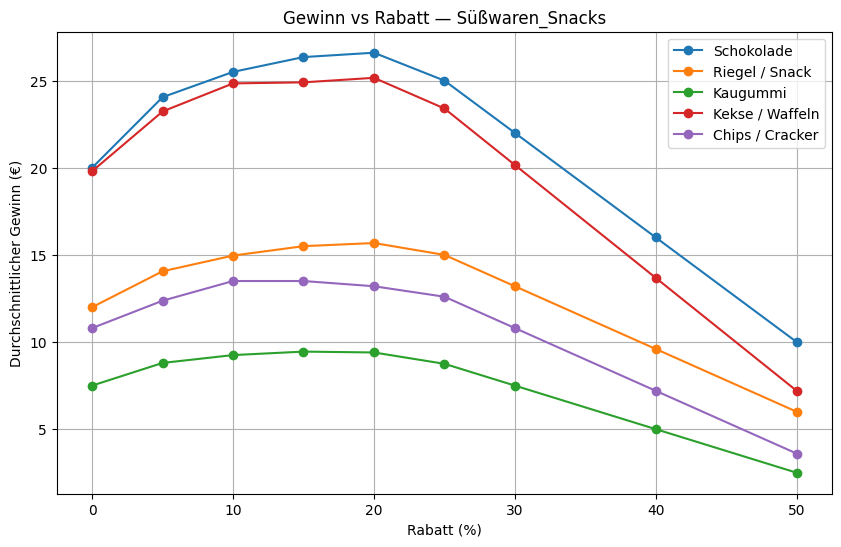

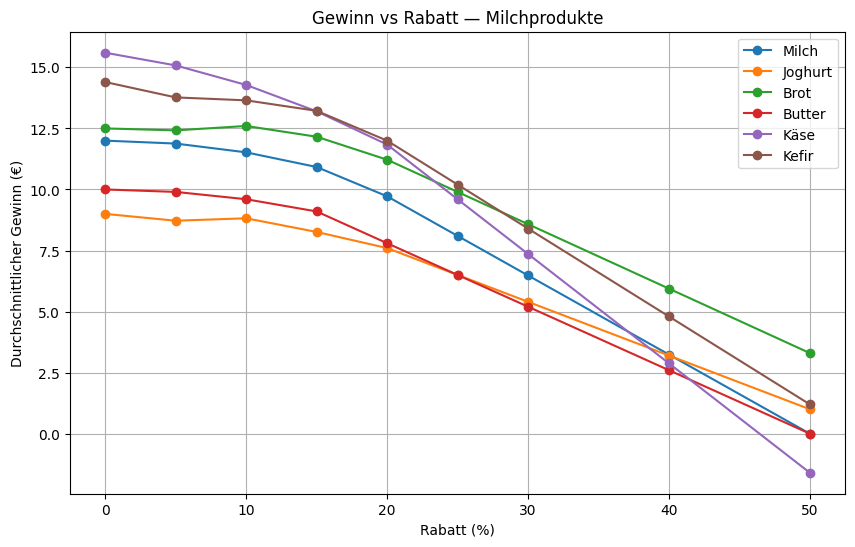

In [6]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# ------------------- Daten -------------------
dates = pd.date_range(datetime(2025,1,1), datetime(2025,3,31))

# ------------------- Elektronikprodukte -------------------
electronics_products = {
    "TV": {"base_qty": 7, "cost": 500, "price": 800,
           "growth": {0:1.0, 5:1.2, 10:1.4, 15:1.35, 20:1.3, 25:1.25, 30:1.25, 40:1.2, 50:1.15}},
    "Waschmaschinen": {"base_qty": 4, "cost": 300, "price": 600,
           "growth": {0:1.0, 5:1.25, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.2, 40:1.15, 50:1.1}},
    "Geschirrspüler": {"base_qty": 3, "cost": 250, "price": 500,
           "growth": {0:1.0, 5:1.45, 10:1.3, 15:1.25, 20:1.2, 25:1.2, 30:1.15, 40:1.1, 50:1.05}},
    "Kühlschränke": {"base_qty": 5, "cost": 800, "price": 1200,
           "growth": {0:1.0, 5:1.39, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.15, 40:1.1, 50:1.05}}
}

# ------------------- Impulsprodukte -------------------
impulse_products = {
    "Schokolade": {"base_qty": 20, "cost": 0.5, "price": 1.5},
    "Riegel / Snack": {"base_qty": 15, "cost": 0.4, "price": 1.2},
    "Kaugummi": {"base_qty": 25, "cost": 0.2, "price": 0.5},
    "Kekse / Waffeln": {"base_qty": 18, "cost": 0.7, "price": 1.8},
    "Chips / Cracker": {"base_qty": 12, "cost": 0.6, "price": 1.5}
}

# ------------------- Milchprodukte -------------------
milk_products = {
    "Milch": {"base_qty": 20, "cost": 0.6, "price": 1.2},
    "Joghurt": {"base_qty": 15, "cost": 0.5, "price": 1.1},
    "Brot": {"base_qty": 25, "cost": 0.3, "price": 0.8},
    "Butter": {"base_qty": 10, "cost": 1.0, "price": 2.0},
    "Käse": {"base_qty": 12, "cost": 1.5, "price": 2.8},
    "Kefir": {"base_qty": 18, "cost": 0.7, "price": 1.5}
}

# ------------------- Alle Produkte -------------------
all_products = {**electronics_products, **impulse_products, **milk_products}

# ------------------- Kategorien -------------------
product_category = {
    **{k: {"category": "NonFood", "sub_category": "Elektronik"} for k in electronics_products},
    **{k: {"category": "Lebensmittel", "sub_category": "Süßwaren_Snacks"} for k in impulse_products},
    **{k: {"category": "Lebensmittel", "sub_category": "Milchprodukte"} for k in milk_products}
}

# ------------------- Rabatte -------------------
discounts = [0,5,10,15,20,25,30,40,50]

# ------------------- Mengenlogik -------------------
def calc_qty(product, discount):
    if product in electronics_products:
        base = electronics_products[product]["base_qty"]
        return int(base * electronics_products[product]["growth"][discount])
    elif product in impulse_products:
        base = impulse_products[product]["base_qty"]
        mapping = {0:base,5:base*1.3,10:base*1.5,15:base*1.7,
                   20:base*1.9,25:base*2.0,30:base*2.0,40:base*2.0,50:base*2.0}
        return int(mapping[discount])
    else:
        base = milk_products[product]["base_qty"]
        mapping = {0:base,5:int(base*1.1),10:int(base*1.2),15:int(base*1.3),
                   20:int(base*1.35),25:int(base*1.35),30:int(base*1.35),
                   40:int(base*1.35),50:int(base*1.35)}
        return mapping[discount]

# ------------------- Datengenerierung -------------------
data = []
np.random.seed(42)

for date in dates:
    for product, params in all_products.items():
        discount = np.random.choice(discounts)
        qty = calc_qty(product, discount)
        price_discounted = params["price"] * (1 - discount/100)
        profit = (price_discounted - params["cost"]) * qty

        cat = product_category[product]["category"]
        sub = product_category[product]["sub_category"]

        data.append([
            date, product, cat, sub, qty,
            params["cost"], params["price"], discount,
            round(price_discounted,2), round(profit,2)
        ])

df_all = pd.DataFrame(data, columns=[
    "Datum","Produkt","Kategorie","Unterkategorie","Menge",
    "Stückkosten (€)","Listenpreis (€)","Rabatt (%)",
    "Preis mit Rabatt (€)","Gewinn (€)"
])

df_all.to_excel("orders_all_products_combined_V_3_2_DE.xlsx", index=False)

# ------------------- Diagramme -------------------
for sub in df_all["Unterkategorie"].unique():
    plt.figure(figsize=(10,6))
    for product in df_all[df_all["Unterkategorie"]==sub]["Produkt"].unique():
        df_p = df_all[df_all["Produkt"]==product].groupby("Rabatt (%)")["Gewinn (€)"].mean().reset_index()
        plt.plot(df_p["Rabatt (%)"], df_p["Gewinn (€)"], marker="o", label=product)
    plt.title(f"Gewinn vs Rabatt — {sub}")
    plt.xlabel("Rabatt (%)")
    plt.ylabel("Durchschnittlicher Gewinn (€)")
    plt.legend()
    plt.grid(True)
    plt.show()


# Kaufland Edeka

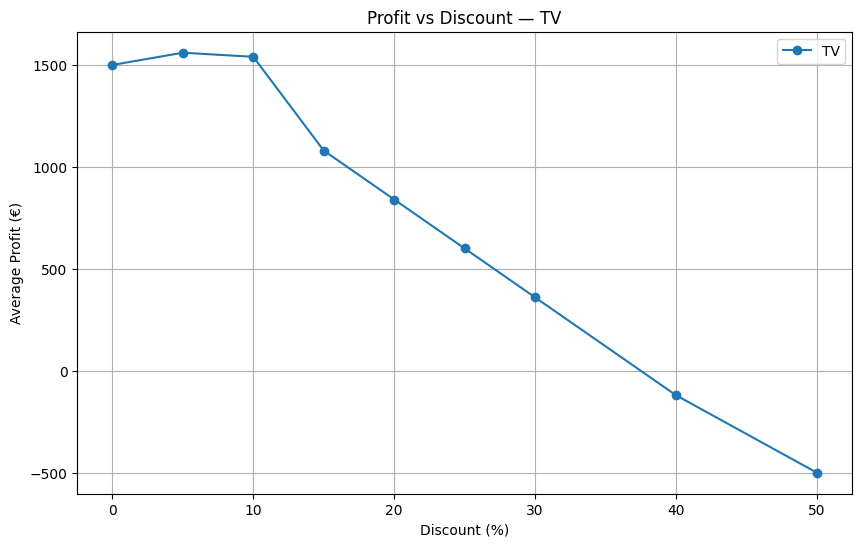

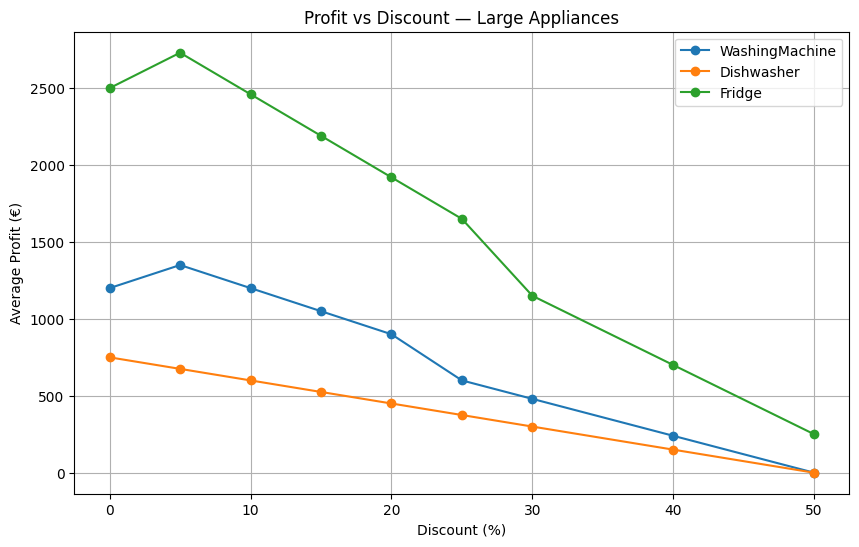

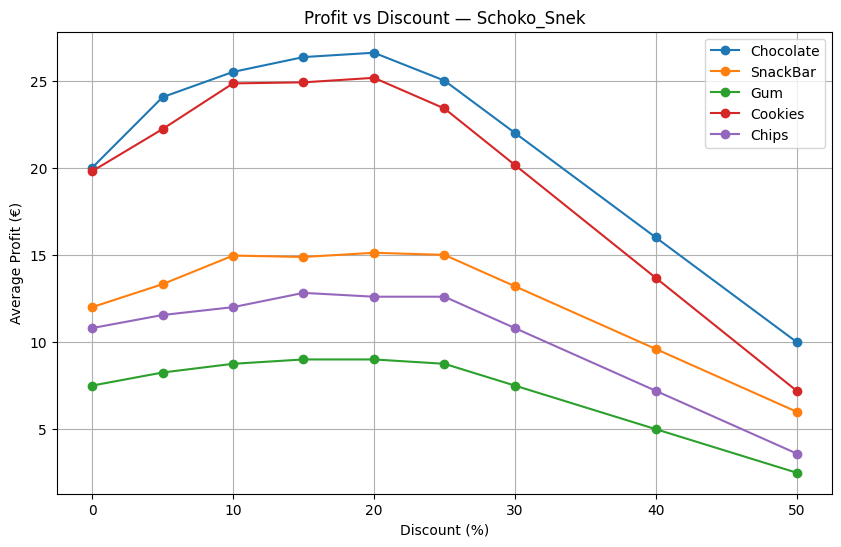

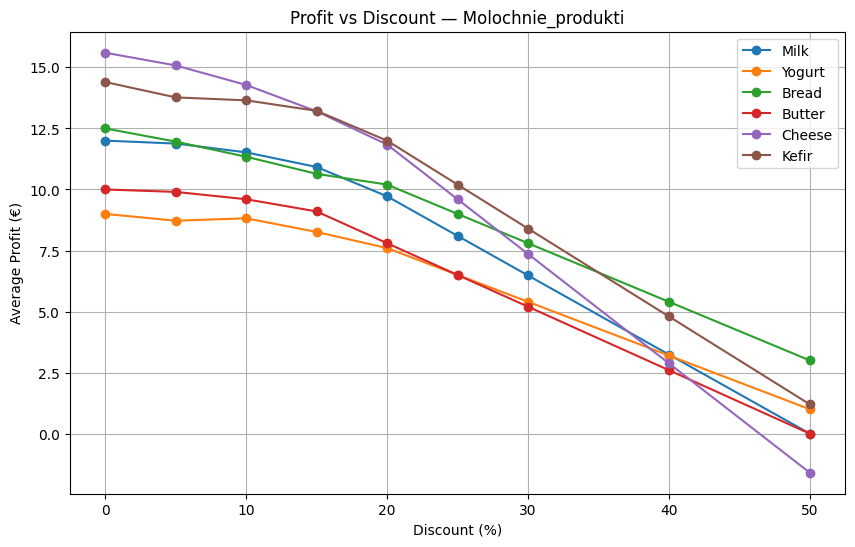

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# ------------------- Даты -------------------
dates = pd.date_range(datetime(2025,1,1), datetime(2025,3,31))

# ------------------- Все продукты -------------------
products = {
    # Electronics
    "TV":             {"category":"Electronics", "sub_category":"TV", "base_qty":5, "cost":500, "price":800,
                       "growth": {0:1.0, 5:1.2, 10:1.4, 15:1.35, 20:1.3, 25:1.25, 30:1.25, 40:1.2, 50:1.15}},
    "WashingMachine": {"category":"Electronics", "sub_category":"Large Appliances", "base_qty":4, "cost":300, "price":600,
                       "growth": {0:1.0, 5:1.25, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.2, 40:1.15, 50:1.1}},
    "Dishwasher":     {"category":"Electronics", "sub_category":"Large Appliances", "base_qty":3, "cost":250, "price":500,
                       "growth": {0:1.0, 5:1.15, 10:1.3, 15:1.25, 20:1.2, 25:1.2, 30:1.15, 40:1.1, 50:1.05}},
    "Fridge":         {"category":"Electronics", "sub_category":"Large Appliances", "base_qty":5, "cost":400, "price":900,
                       "growth": {0:1.0, 5:1.2, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.15, 40:1.1, 50:1.05}},

    # Sweets / Impulse
    "Chocolate":      {"category":"Food", "sub_category":"Schoko_Snek", "base_qty":20, "cost":0.5, "price":1.5,
                       "growth": {0:1.0, 5:1.3, 10:1.5, 15:1.7, 20:1.9, 25:2.0, 30:2.0, 40:2.0, 50:2.0}},
    "SnackBar":       {"category":"Food", "sub_category":"Schoko_Snek", "base_qty":15, "cost":0.4, "price":1.2,
                       "growth": {0:1.0, 5:1.25, 10:1.5, 15:1.65, 20:1.8, 25:2.0, 30:2.0, 40:2.0, 50:2.0}},
    "Gum":            {"category":"Food", "sub_category":"Schoko_Snek", "base_qty":25, "cost":0.2, "price":0.5,
                       "growth": {0:1.0, 5:1.2, 10:1.4, 15:1.6, 20:1.8, 25:2.0, 30:2.0, 40:2.0, 50:2.0}},
    "Cookies":        {"category":"Food", "sub_category":"Schoko_Snek", "base_qty":18, "cost":0.7, "price":1.8,
                       "growth": {0:1.0, 5:1.25, 10:1.5, 15:1.7, 20:1.9, 25:2.0, 30:2.0, 40:2.0, 50:2.0}},
    "Chips":          {"category":"Food", "sub_category":"Schoko_Snek", "base_qty":12, "cost":0.6, "price":1.5,
                       "growth": {0:1.0, 5:1.2, 10:1.4, 15:1.6, 20:1.8, 25:2.0, 30:2.0, 40:2.0, 50:2.0}},

    # Dairy
    "Milk":           {"category":"Food", "sub_category":"Molochnie_produkti", "base_qty":20, "cost":0.6, "price":1.2,
                       "growth": {0:1.0, 5:1.1, 10:1.2, 15:1.3, 20:1.35, 25:1.35, 30:1.35, 40:1.35, 50:1.35}},
    "Yogurt":         {"category":"Food", "sub_category":"Molochnie_produkti", "base_qty":15, "cost":0.5, "price":1.1,
                       "growth": {0:1.0, 5:1.1, 10:1.2, 15:1.3, 20:1.35, 25:1.35, 30:1.35, 40:1.35, 50:1.35}},
    "Bread":          {"category":"Food", "sub_category":"Molochnie_produkti", "base_qty":25, "cost":0.3, "price":0.8,
                       "growth": {0:1.0, 5:1.05, 10:1.1, 15:1.15, 20:1.2, 25:1.2, 30:1.2, 40:1.2, 50:1.2}},
    "Butter":         {"category":"Food", "sub_category":"Molochnie_produkti", "base_qty":10, "cost":1.0, "price":2.0,
                       "growth": {0:1.0, 5:1.1, 10:1.2, 15:1.3, 20:1.35, 25:1.35, 30:1.35, 40:1.35, 50:1.35}},
    "Cheese":         {"category":"Food", "sub_category":"Molochnie_produkti", "base_qty":12, "cost":1.5, "price":2.8,
                       "growth": {0:1.0, 5:1.1, 10:1.2, 15:1.3, 20:1.35, 25:1.35, 30:1.35, 40:1.35, 50:1.35}},
    "Kefir":          {"category":"Food", "sub_category":"Molochnie_produkti", "base_qty":18, "cost":0.7, "price":1.5,
                       "growth": {0:1.0, 5:1.1, 10:1.2, 15:1.3, 20:1.35, 25:1.35, 30:1.35, 40:1.35, 50:1.35}}
}

# ------------------- Доступные скидки -------------------
discounts = [0, 5, 10, 15, 20, 25, 30, 40, 50]

# ------------------- Функция для расчета qty -------------------
def calc_qty(product, discount):
    base = products[product]["base_qty"]
    qty = base * products[product]["growth"][discount]
    return int(qty)

# ------------------- Генерация данных -------------------
data = []
np.random.seed(42)

for date in dates:
    for product, params in products.items():
        discount = np.random.choice(discounts)
        qty = calc_qty(product, discount)
        price_discounted = params["price"] * (1 - discount/100)
        profit = (price_discounted - params["cost"]) * qty

        data.append([
            date, product, params["category"], params["sub_category"], qty,
            params["cost"], params["price"], discount,
            round(price_discounted,2), round(profit,2)
        ])

# ------------------- Создание DataFrame -------------------
df_all = pd.DataFrame(
    data,
    columns=[
        "Date", "Product", "Category", "Sub_Category", "Qty",
        "Cost_per_unit", "Price_no_discount", "Discount_%",
        "Price_discounted", "Profit"
    ]
)

# ------------------- Экспорт -------------------
df_all.to_excel("df_realistic_stores_Kaufland_Edeka_2.xlsx", index=False)

# ------------------- Построение графиков -------------------
for sub_cat in df_all["Sub_Category"].unique():
    plt.figure(figsize=(10,6))
    for product in df_all[df_all["Sub_Category"]==sub_cat]["Product"].unique():
        df_p = (
            df_all[df_all["Product"]==product]
            .groupby("Discount_%")["Profit"]
            .mean()
            .reset_index()
            .sort_values("Discount_%")
        )
        plt.plot(df_p["Discount_%"], df_p["Profit"], marker="o", label=product)
    plt.xlabel("Discount (%)")
    plt.ylabel("Average Profit (€)")
    plt.title(f"Profit vs Discount — {sub_cat}")
    plt.legend()
    plt.grid(True)
    plt.show()


# Kaufland Sdeka Penetration

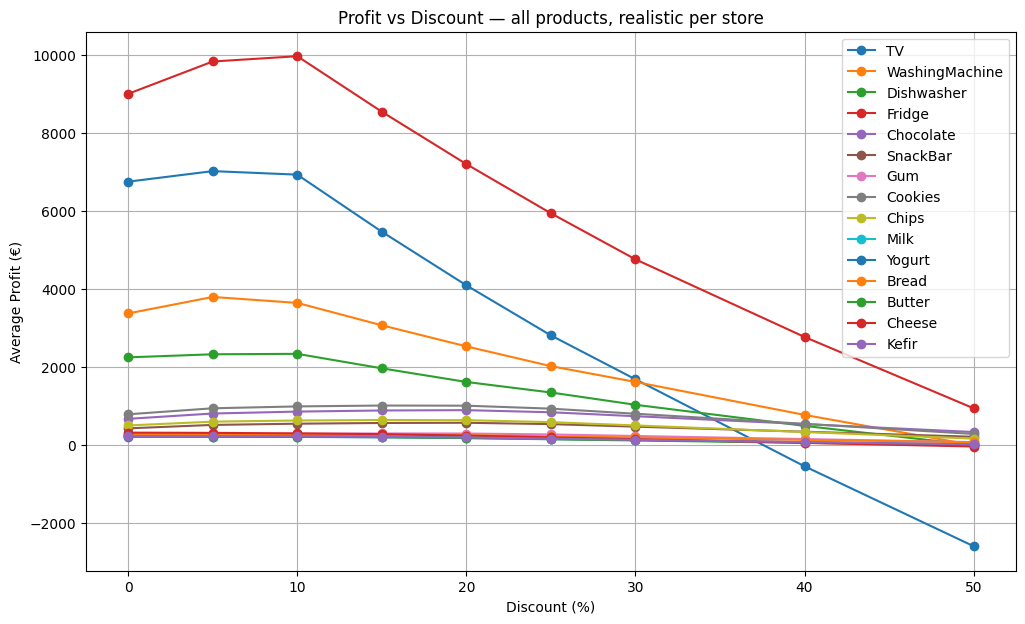

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# ------------------- Даты -------------------
dates = pd.date_range(datetime(2025,1,1), datetime(2025,3,31))

# ------------------- Магазины -------------------
stores = {
    "EDEKA": 1000,
    "Kaufland": 3500
}

# ------------------- Товары -------------------
products = {
    # Электроника
    "TV":             {"category":"Electronics", "sub_category":"TV", "cost":500, "price":800,
                       "growth": {0:1.0, 5:1.2, 10:1.4, 15:1.35, 20:1.3, 25:1.25, 30:1.25, 40:1.2, 50:1.15}},
    "WashingMachine": {"category":"Electronics", "sub_category":"Large Appliances", "cost":300, "price":600,
                       "growth": {0:1.0, 5:1.25, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.2, 40:1.15, 50:1.1}},
    "Dishwasher":     {"category":"Electronics", "sub_category":"Large Appliances", "cost":250, "price":500,
                       "growth": {0:1.0, 5:1.15, 10:1.3, 15:1.25, 20:1.2, 25:1.2, 30:1.15, 40:1.1, 50:1.05}},
    "Fridge":         {"category":"Electronics", "sub_category":"Large Appliances", "cost":400, "price":900,
                       "growth": {0:1.0, 5:1.2, 10:1.35, 15:1.3, 20:1.25, 25:1.2, 30:1.15, 40:1.1, 50:1.05}},
    # Импульсивные
    "Chocolate":      {"category":"Food", "sub_category":"Schoko_Snek", "cost":0.5, "price":1.5,
                       "growth": {0:1.0,5:1.3,10:1.5,15:1.7,20:1.9,25:2.0,30:2.0,40:2.0,50:2.0}},
    "SnackBar":       {"category":"Food", "sub_category":"Schoko_Snek", "cost":0.4, "price":1.2,
                       "growth": {0:1.0,5:1.3,10:1.5,15:1.7,20:1.9,25:2.0,30:2.0,40:2.0,50:2.0}},
    "Gum":            {"category":"Food", "sub_category":"Schoko_Snek", "cost":0.2, "price":0.5,
                       "growth": {0:1.0,5:1.3,10:1.5,15:1.7,20:1.9,25:2.0,30:2.0,40:2.0,50:2.0}},
    "Cookies":        {"category":"Food", "sub_category":"Schoko_Snek", "cost":0.7, "price":1.8,
                       "growth": {0:1.0,5:1.3,10:1.5,15:1.7,20:1.9,25:2.0,30:2.0,40:2.0,50:2.0}},
    "Chips":          {"category":"Food", "sub_category":"Schoko_Snek", "cost":0.6, "price":1.5,
                       "growth": {0:1.0,5:1.3,10:1.5,15:1.7,20:1.9,25:2.0,30:2.0,40:2.0,50:2.0}},
    # Молочные
    "Milk":           {"category":"Food", "sub_category":"Molochnie_produkti", "cost":0.6, "price":1.2,
                       "growth": {0:1.0,5:1.1,10:1.2,15:1.3,20:1.35,25:1.35,30:1.35,40:1.35,50:1.35}},
    "Yogurt":         {"category":"Food", "sub_category":"Molochnie_produkti", "cost":0.5, "price":1.1,
                       "growth": {0:1.0,5:1.1,10:1.2,15:1.3,20:1.35,25:1.35,30:1.35,40:1.35,50:1.35}},
    "Bread":          {"category":"Food", "sub_category":"Molochnie_produkti", "cost":0.3, "price":0.8,
                       "growth": {0:1.0,5:1.1,10:1.2,15:1.3,20:1.35,25:1.35,30:1.35,40:1.35,50:1.35}},
    "Butter":         {"category":"Food", "sub_category":"Molochnie_produkti", "cost":1.0, "price":2.0,
                       "growth": {0:1.0,5:1.1,10:1.2,15:1.3,20:1.35,25:1.35,30:1.35,40:1.35,50:1.35}},
    "Cheese":         {"category":"Food", "sub_category":"Molochnie_produkti", "cost":1.5, "price":2.8,
                       "growth": {0:1.0,5:1.1,10:1.2,15:1.3,20:1.35,25:1.35,30:1.35,40:1.35,50:1.35}},
    "Kefir":          {"category":"Food", "sub_category":"Molochnie_produkti", "cost":0.7, "price":1.5,
                       "growth": {0:1.0,5:1.1,10:1.2,15:1.3,20:1.35,25:1.35,30:1.35,40:1.35,50:1.35}},
}

# ------------------- Penetration rate -------------------
penetration = {
    "TV":0.01, "WashingMachine":0.005, "Dishwasher":0.004, "Fridge":0.008,
    "Chocolate":0.30, "SnackBar":0.24, "Gum":0.35, "Cookies":0.32, "Chips":0.25,
    "Milk":0.2, "Yogurt":0.16, "Bread":0.25, "Butter":0.1, "Cheese":0.11, "Kefir":0.13
}

# ------------------- Discounts -------------------
discounts = [0,5,10,15,20,25,30,40,50]

# ------------------- Генерация DF -------------------
data = []
np.random.seed(42)

for store_name, traffic in stores.items():
    for date in dates:
        for product, info in products.items():
            #discount = np.random.choice(discounts)
            week_number = (date - dates[0]).days // 7
            #discount = discounts[min(week_number, len(discounts) - 1)]
            discount = discounts[week_number % len(discounts)]
            qty = traffic * penetration[product] * info["growth"][discount]
            price_discounted = info["price"] * (1 - discount/100)
            profit = (price_discounted - info["cost"]) * qty
            data.append([
                date, store_name, product, info["category"], info["sub_category"],
                round(qty,1), info["cost"], info["price"], discount,
                round(price_discounted,2), round(profit,2)
            ])

df = pd.DataFrame(data, columns=[
    "Date","Store","Product","Category","SubCategory",
    "Qty","Cost","Price","Discount","Price_Discounted","Profit"
])

# ------------------- Export -------------------
df.to_excel("realistic_products_by_store_penetration_KW-Cycle_Shum.xlsx", index=False)

# ------------------- Plot Profit vs Discount -------------------
plt.figure(figsize=(12,7))
for product in df["Product"].unique():
    df_p = df.groupby(["Discount","Product"])["Profit"].mean().reset_index()
    df_plot = df_p[df_p["Product"]==product].sort_values("Discount")
    plt.plot(df_plot["Discount"], df_plot["Profit"], marker="o", label=product)
plt.xlabel("Discount (%)")
plt.ylabel("Average Profit (€)")
plt.title("Profit vs Discount — all products, realistic per store")
plt.legend()
plt.grid(True)
plt.show()
